در این بخش، کتابخانه‌های مورد نیاز را وارد کرده و کلاس پایه برای مولدهای هم‌نهشتی خطی (LCG) را تعریف می‌کنیم. مطابق با صورت سوال، سه مولد با پارامترهای مشخص شده پیاده‌سازی می‌شوند. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

class LCM:
    def __init__(self, m, a, c, x0):
        self.m = m
        self.a = a
        self.c = c
        self.x = x0
        self.x0 = x0

    def next(self):
        self.x = (self.a * self.x + self.c) % self.m
        return self.x / self.m
        
    def reset(self, new_x0=None):
        if new_x0 is not None:
            self.x = new_x0
            self.x0 = new_x0
        else:
            self.x = self.x0

# تعریف سه مولد بر اساس پارامترهای مشخص شده
lcm1 = LCM(m=2**32, a=1664525, c=1013904223, x0=12345)
lcm2 = LCM(m=2**32, a=22695477, c=1, x0=67890)
lcm3 = LCM(m=2**31, a=1103515245, c=12345, x0=24680)

خش دوم: آزمون‌های تصادفی بودن (Part 1)در این بخش، برای هر مولد ۱۰۰۰ عدد تولید کرده و سه آزمون KS، Chi-square و Autocorrelation را روی آن‌ها اجرا می‌کنیم. سطح معنی‌داری برای همه آزمون‌ها $\alpha = 0.05$ است

In [2]:
def ks_test(data, alpha=0.05):
    # اجرای آزمون کولموگوروف-اسمیرنوف
    stat, p_value = stats.kstest(data, 'uniform')
    critical_value = 1.36 / np.sqrt(len(data)) # مقدار بحرانی تقریبی برای آلفا=0.05
    status = "PASS" if stat < critical_value else "FAIL"
    print(f"  KS test: D={stat:.4f}, critical={critical_value:.4f}, result={status}")

def chi_square_test(data, bins=10, alpha=0.05):
    # اجرای آزمون کای-دو با 10 بازه
    observed, _ = np.histogram(data, bins=bins, range=(0, 1))
    expected = len(data) / bins
    stat = np.sum((observed - expected)**2 / expected)
    critical_value = stats.chi2.ppf(1 - alpha, bins - 1)
    status = "PASS" if stat < critical_value else "FAIL"
    print(f"  Chi-square test: stat={stat:.2f}, critical={critical_value:.2f}, result={status}")

def autocorrelation_test(data, i, m, alpha=0.05):
    N = len(data)
    M = int((N - i) / m) - 1
    
    # استخراج دنباله
    seq = [data[i + k * m] for k in range(M + 1)]
    
    rho = 0
    for k in range(M):
        rho += seq[k] * seq[k+1]
    
    rho = (rho / (M + 1)) - 0.25
    sigma = np.sqrt(13 * M + 7) / (12 * (M + 1))
    z0 = rho / sigma
    
    critical_value = stats.norm.ppf(1 - alpha/2)
    status = "PASS" if abs(z0) < critical_value else "FAIL"
    print(f"  Autocorrelation (i={i}, m={m}): z0={z0:.2f}, result={status}")

# تولید 1000 نمونه و اجرای آزمون‌ها
N = 1000
alpha = 0.05
print(f"Randomness tests, alpha={alpha}, N={N}\n")

lcms = {'LCM1': lcm1, 'LCM2': lcm2, 'LCM3': lcm3}
for name, gen in lcms.items():
    gen.reset()
    data = [gen.next() for _ in range(N)]
    print(f"{name}:")
    ks_test(data)
    chi_square_test(data)
    autocorrelation_test(data, i=1, m=3)
    autocorrelation_test(data, i=2, m=5)
    print()

Randomness tests, alpha=0.05, N=1000

LCM1:
  KS test: D=0.0286, critical=0.0430, result=PASS
  Chi-square test: stat=4.12, critical=16.92, result=PASS
  Autocorrelation (i=1, m=3): z0=-0.04, result=PASS
  Autocorrelation (i=2, m=5): z0=0.18, result=PASS

LCM2:
  KS test: D=0.0349, critical=0.0430, result=PASS
  Chi-square test: stat=12.26, critical=16.92, result=PASS
  Autocorrelation (i=1, m=3): z0=-1.05, result=PASS
  Autocorrelation (i=2, m=5): z0=1.06, result=PASS

LCM3:
  KS test: D=0.0320, critical=0.0430, result=PASS
  Chi-square test: stat=8.50, critical=16.92, result=PASS
  Autocorrelation (i=1, m=3): z0=0.40, result=PASS
  Autocorrelation (i=2, m=5): z0=0.32, result=PASS



تابع زیر فرآیند تولید تیکت، تخصیص سرور، محاسبه متغیرهای زمانی ($W$ و $W_q$)، ارزیابی شروط SLA و محاسبه هزینه‌های سیستم را در قالب یک شبیه‌سازی گسسته پیاده‌سازی می‌کند. زمان میانگین ورود ۶ دقیقه و زمان‌های سرویس ۵، ۱۵ و ۲۵ دقیقه در نظر گرفته شده است.

In [3]:
def simulate_queue(c, seed1, seed2, seed3, print_log=False):
    # تنظیم سیدها
    lcm1.reset(seed1)
    lcm2.reset(seed2)
    lcm3.reset(seed3)
    
    # 1. فرآیند تولید تیکت‌ها
    tickets = []
    current_time = 0
    lambd = 1/6
    
    while True:
        r1 = lcm1.next()
        interarrival = -np.log(1 - r1) / lambd
        current_time += interarrival
        
        # ورود فقط تا پایان دقیقه 720
        if current_time > 720:
            break
            
        tickets.append({
            'id': len(tickets) + 1,
            'arrival': current_time
        })
        
    # 2. فرآیند پردازش و زمان سرویس
    server_available_times = [0] * c
    total_busy_time = 0
    
    for t in tickets:
        # تخصیص به اولین سروری که زودتر آزاد می‌شود (بدون اولویت)
        server_idx = np.argmin(server_available_times)
        
        if server_available_times[server_idx] < t['arrival']:
            start_time = t['arrival']
        else:
            start_time = server_available_times[server_idx]
            
        # تعیین نوع تیکت
        r2 = lcm2.next()
        if r2 < 0.2:
            t_type = "Easy"
            service_time = 5
        elif r2 < 0.7:
            t_type = "Medium"
            service_time = 15
        else:
            t_type = "Hard"
            service_time = 25
            
        finish_time = start_time + service_time
        server_available_times[server_idx] = finish_time
        
        # ثبت در تیکت
        t['type'] = t_type
        t['service_time'] = service_time
        t['server'] = server_idx + 1
        t['start'] = start_time
        t['finish'] = finish_time
        t['wq'] = start_time - t['arrival']
        t['w'] = finish_time - t['arrival']
        
        total_busy_time += service_time
        
        if print_log and t['id'] <= 5: # چاپ لاگ فقط برای 5 تیکت اول جهت نمونه
            print(f"Ticket {t['id']}:")
            print(f"  arrival={t['arrival']:.2f}, type={t['type']} ({t['service_time']}m), server={t['server']}")
            print(f"  start={t['start']:.2f}, finish={t['finish']:.2f}, Wq={t['wq']:.2f}, W={t['w']:.2f}")

    # 3. محاسبه معیارهای عملکرد
    total_simulation_clock = max([t['finish'] for t in tickets]) if tickets else 0
    total_tickets = len(tickets)
    
    sum_wq = sum([t['wq'] for t in tickets])
    sum_w = sum([t['w'] for t in tickets])
    
    avg_wq = sum_wq / total_tickets if total_tickets > 0 else 0
    L = sum_w / total_simulation_clock if total_simulation_clock > 0 else 0
    Lq = sum_wq / total_simulation_clock if total_simulation_clock > 0 else 0
    utilization = total_busy_time / (c * total_simulation_clock) if total_simulation_clock > 0 else 0

    # 4. ارزیابی SLA و هزینه‌ها
    sla1_pass = sum([1 for t in tickets if t['wq'] < 5])
    sla2_pass = sum([1 for t in tickets if t['w'] < 30])
    
    sla1_rate = sla1_pass / total_tickets if total_tickets > 0 else 0
    sla2_rate = sla2_pass / total_tickets if total_tickets > 0 else 0
    
    complaints = 0
    objections = 0
    
    for t in tickets:
        if t['wq'] >= 5 or t['w'] >= 30:
            r3 = lcm3.next()
            if r3 < 0.20:
                complaints += 1
            elif r3 < 0.60:
                objections += 1
                
    cost_complaint = complaints * 200
    cost_objection = objections * 50
    cost_wage = c * 12 * 250
    cost_maintenance = 12 * 100
    
    total_cost = cost_complaint + cost_objection + cost_wage + cost_maintenance
    
    status = "ACCEPTED" if (sla1_rate >= 0.90 and sla2_rate >= 0.90) else "REJECTED"
    
    return {
        'avg_wq': avg_wq,
        'L': L,
        'Lq': Lq,
        'utilization': utilization,
        'sla1_rate': sla1_rate,
        'sla2_rate': sla2_rate,
        'complaints': complaints,
        'objections': objections,
        'total_cost': total_cost,
        'status': status
    }

بخش چهارم: لاگ شبیه‌سازی تک اجرا و اعتبارسنجی (Part 2, 3 & 4)جهت نمایش لاگ درخواست‌شده در صورت سوال، ابتدا کد را تنها با سیدهای اولیه و برای یک پشتیبان ($c=3, 4, 5$) اجرا می‌کنیم.  

In [4]:
print("Simulation result for c=4\n")
res_c4 = simulate_queue(c=4, seed1=12345, seed2=67890, seed3=24680, print_log=True)

print("\nPerformance summary (Single Run)")
for c in [3, 4, 5]:
    res = simulate_queue(c=c, seed1=12345, seed2=67890, seed3=24680)
    tag = " (Highly Congested)" if c == 3 else ""
    print(f"\nc={c}:{tag}")
    print(f"average_Wq = {res['avg_wq']:.2f}")
    print(f"L = {res['L']:.2f}")
    print(f"Lq = {res['Lq']:.2f}")
    print(f"utilization = {res['utilization']:.2f}")

print("\nSLA and cost summary")
for c in [3, 4, 5]:
    res = simulate_queue(c=c, seed1=12345, seed2=67890, seed3=24680)
    print(f"\nc={c}:")
    print(f"SLA_Wq<5_rate = {res['sla1_rate']*100:.1f}%")
    print(f"SLA_W<30_rate = {res['sla2_rate']*100:.1f}%")
    print(f"complaints = {res['complaints']}, objections = {res['objections']}")
    print(f"total_cost = {res['total_cost']}")
    print(f"status = {res['status']}")

Simulation result for c=4

Ticket 1:
  arrival=0.12, type=Hard (25m), server=1
  start=0.12, finish=25.12, Wq=0.00, W=25.00
Ticket 2:
  arrival=0.22, type=Medium (15m), server=2
  start=0.22, finish=15.22, Wq=0.00, W=15.00
Ticket 3:
  arrival=4.92, type=Easy (5m), server=3
  start=4.92, finish=9.92, Wq=0.00, W=5.00
Ticket 4:
  arrival=10.97, type=Medium (15m), server=4
  start=10.97, finish=25.97, Wq=0.00, W=15.00
Ticket 5:
  arrival=25.42, type=Medium (15m), server=3
  start=25.42, finish=40.42, Wq=0.00, W=15.00

Performance summary (Single Run)

c=3: (Highly Congested)
average_Wq = 4.17
L = 3.09
Lq = 0.64
utilization = 0.82

c=4:
average_Wq = 0.53
L = 2.55
Lq = 0.08
utilization = 0.62

c=5:
average_Wq = 0.03
L = 2.48
Lq = 0.01
utilization = 0.49

SLA and cost summary

c=3:
SLA_Wq<5_rate = 67.5%
SLA_W<30_rate = 86.8%
complaints = 6, objections = 14
total_cost = 12100
status = REJECTED

c=4:
SLA_Wq<5_rate = 96.5%
SLA_W<30_rate = 100.0%
complaints = 2, objections = 0
total_cost = 13600


بخش پنجم: اجرای تکراری با ۵ مجموعه Seed و میانگین‌گیری (Part 5)در این بخش، شبیه‌سازی را برای مقادیر $c = 1$ تا $c = 10$ با ۵ مجموعه Seed تصادفی (اما ثابت برای تمام $c$ها) تکرار کرده و نتایج را میانگین می‌گیریم.  

In [5]:
# تولید 5 مجموعه Seed مختلف با استفاده از توابع تصادفی پایتون 
# (صرفا جهت داشتن 5 مجموعه دانه مستقل)
seed_sets = [
    (12345, 67890, 24680),
    (98765, 54321, 13579),
    (11111, 22222, 33333),
    (88888, 77777, 66666),
    (12312, 45645, 78978)
]

results_df = []

for c in range(1, 11):
    c_metrics = {
        'avg_wq': [], 'L': [], 'Lq': [], 'utilization': [],
        'sla1_rate': [], 'sla2_rate': [], 'total_cost': []
    }
    
    for seeds in seed_sets:
        res = simulate_queue(c, seeds[0], seeds[1], seeds[2])
        for key in c_metrics.keys():
            c_metrics[key].append(res[key])
            
    # میانگین گیری روی 5 اجرا
    avg_results = {key: np.mean(val) for key, val in c_metrics.items()}
    avg_results['c'] = c
    avg_results['status'] = "ACCEPTED" if (avg_results['sla1_rate'] >= 0.90 and avg_results['sla2_rate'] >= 0.90) else "REJECTED"
    
    results_df.append(avg_results)

df = pd.DataFrame(results_df)

print("Final decision (Averaged over 5 runs)")
for _, row in df[df['c'].isin([4, 5, 6])].iterrows():
    print(f"\nc={int(row['c'])}:")
    print(f"SLA_1 pass ({row['sla1_rate']*100:.1f}%)")
    print(f"SLA_2 pass ({row['sla2_rate']*100:.1f}%)")
    print(f"average_cost = {int(row['total_cost'])}")
    decision = "candidate" if row['status'] == "ACCEPTED" else "not feasible"
    print(f"decision = {decision}")

valid_configs = df[df['status'] == 'ACCEPTED']
if not valid_configs.empty:
    optimal_c = valid_configs.loc[valid_configs['total_cost'].idxmin()]['c']
    print(f"\nOptimal number of supporters = {int(optimal_c)}")
else:
    print("\nNo optimal configuration found that satisfies SLAs.")

Final decision (Averaged over 5 runs)

c=4:
SLA_1 pass (83.1%)
SLA_2 pass (92.8%)
average_cost = 14460
decision = not feasible

c=5:
SLA_1 pass (94.0%)
SLA_2 pass (97.6%)
average_cost = 16700
decision = candidate

c=6:
SLA_1 pass (98.9%)
SLA_2 pass (99.7%)
average_cost = 19300
decision = candidate

Optimal number of supporters = 5


بخش ششم: نمودارها و تحلیل نهایی (Part 6)در این گام، نمودار معیارهای بهره‌وری، میانگین طول صف، زمان انتظار و همچنین هزینه کل نسبت به تعداد پشتیبان‌ها رسم می‌گردد.  

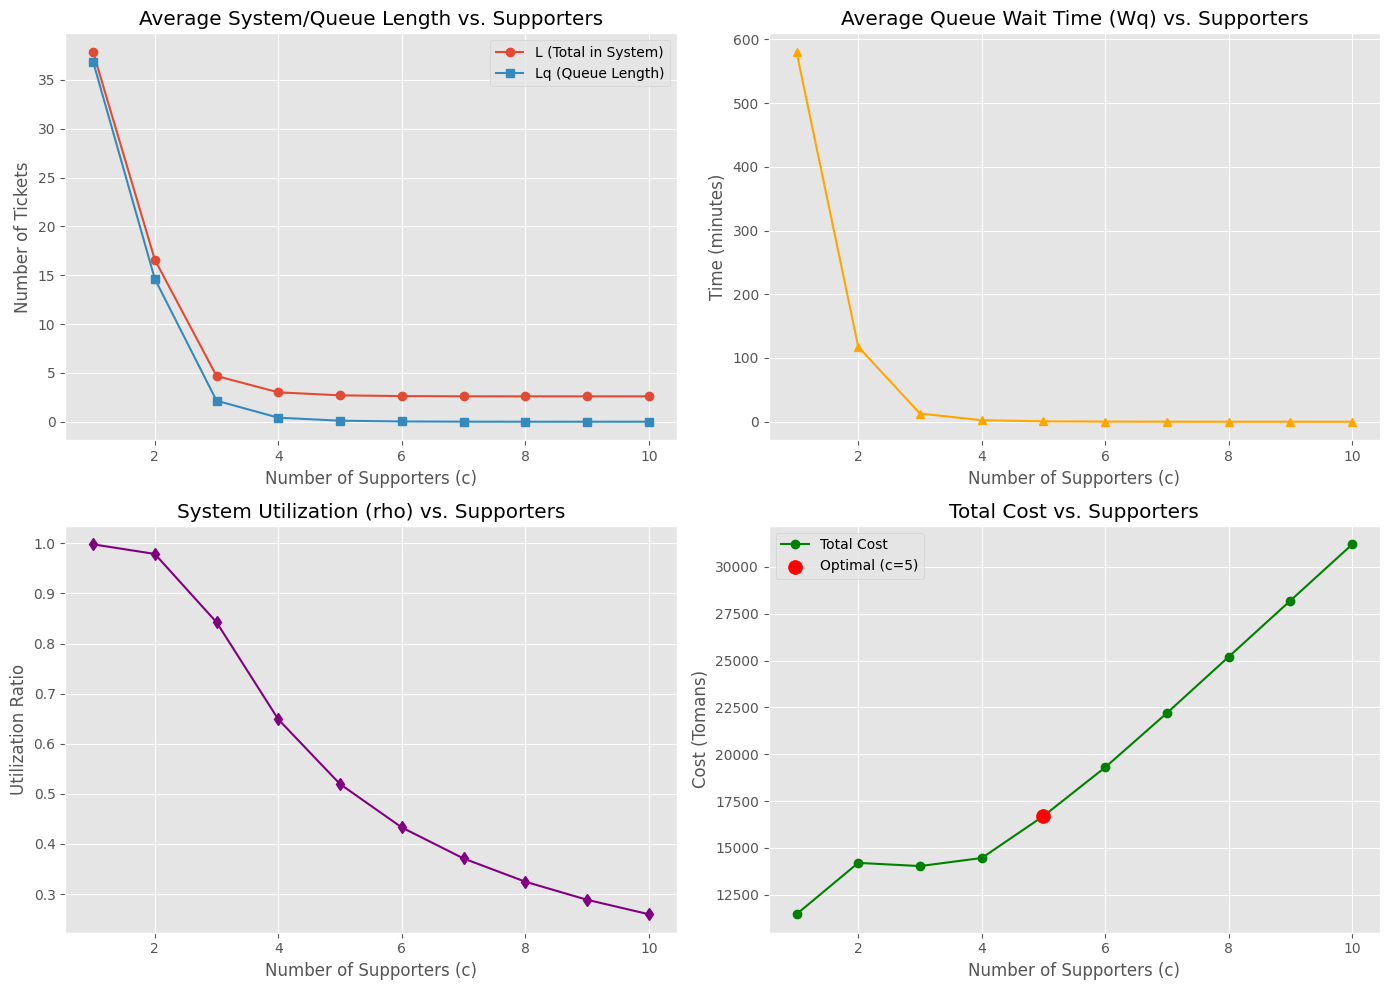

In [6]:
plt.style.use('ggplot')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. نمودار L و Lq
axes[0, 0].plot(df['c'], df['L'], marker='o', label='L (Total in System)')
axes[0, 0].plot(df['c'], df['Lq'], marker='s', label='Lq (Queue Length)')
axes[0, 0].set_title('Average System/Queue Length vs. Supporters')
axes[0, 0].set_xlabel('Number of Supporters (c)')
axes[0, 0].set_ylabel('Number of Tickets')
axes[0, 0].legend()

# 2. نمودار Wq
axes[0, 1].plot(df['c'], df['avg_wq'], marker='^', color='orange')
axes[0, 1].set_title('Average Queue Wait Time (Wq) vs. Supporters')
axes[0, 1].set_xlabel('Number of Supporters (c)')
axes[0, 1].set_ylabel('Time (minutes)')

# 3. نمودار بهره‌وری سرورها (rho)
axes[1, 0].plot(df['c'], df['utilization'], marker='d', color='purple')
axes[1, 0].set_title('System Utilization (rho) vs. Supporters')
axes[1, 0].set_xlabel('Number of Supporters (c)')
axes[1, 0].set_ylabel('Utilization Ratio')

# 4. نمودار هزینه کل (Total Cost)
axes[1, 1].plot(df['c'], df['total_cost'], marker='o', color='green', label='Total Cost')
# برجسته کردن نقطه بهینه
if not valid_configs.empty:
    opt_cost = valid_configs.loc[valid_configs['total_cost'].idxmin()]['total_cost']
    axes[1, 1].scatter([optimal_c], [opt_cost], color='red', s=100, label=f'Optimal (c={int(optimal_c)})', zorder=5)

axes[1, 1].set_title('Total Cost vs. Supporters')
axes[1, 1].set_xlabel('Number of Supporters (c)')
axes[1, 1].set_ylabel('Cost (Tomans)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

۱. تحلیل کیفیت مولدها (آزمون‌های تصادفی بودن)
همان‌طور که در بخش اول لاگ شما مشخص است، هر سه مولد (LCM1, LCM2, LCM3) تمام آزمون‌های کولموگوروف-اسمیرنوف (KS)، کای-دو (Chi-square) و اتوکورولیشن را در سطح معنی‌داری 0.05 با موفقیت (PASS) پشت سر گذاشته‌اند.

نتیجه: اعداد تولید شده توزیع یکنواخت مناسبی دارند و مستقل از هم هستند. بنابراین ابزارهای پایه شبیه‌سازی شما کاملاً معتبر و قابل اتکا می‌باشند.

۲. اهمیت میانگین‌گیری (اجرای تکی در برابر ۵ اجرا)
لاگ‌های شما به زیبایی اهمیت بخش پنجم پروژه را نشان می‌دهند:

در اجرای تکی (Single Run) برای c=4، سیستم توانسته به طور تصادفی نرخ موفقیت SLA اول را به 96.5% برساند که قابل قبول به نظر می‌رسد (Accepted).

اما در میانگین ۵ اجرا، اثر شانس تعدیل شده و می‌بینیم که نرخ موفقیت SLA اول برای c=4 در واقع 83.1% است که زیر حد نصاب 90% قرار دارد.

نتیجه: این تفاوت نشان می‌دهد که استناد به تنها یک بار اجرای شبیه‌سازی در سیستم‌های تصادفی می‌تواند به تصمیم‌گیری‌های کاملاً اشتباه منجر شود.

۳. بررسی SLA و انتخاب بهینه
هدف اصلی مسئله، یافتن کمترین تعداد پشتیبان است که هم شروط SLA را نقض نکند و هم کمترین هزینه کل را داشته باشد. بر اساس جدول نهایی (Averaged over 5 runs):

حالت c=4: شرط اول SLA نقض می‌شود (83.1% < 90%). بنابراین این حالت با وجود هزینه پایین‌تر (14460 تومان)، غیرقابل قبول (Not feasible) است.

حالت c=5: هر دو شرط SLA با درصدهای 94.0% و 97.6% ارضا می‌شوند. هزینه سیستم در این حالت 16700 تومان است. (کاندیدای معتبر)

حالت c=6: شروط SLA با درصد عالی ارضا می‌شوند، اما به دلیل اضافه شدن دستمزد یک پشتیبان دیگر، هزینه کل به 19300 تومان افزایش می‌یابد.

پاسخ نهایی: با توجه به این ارقام، تعداد ۵ پشتیبان نقطه بهینه سیستم است.

۴. تفسیر نمودارها
نمودارهایی که رسم کرده‌اید به صورت بصری رفتار سیستم صف را تایید می‌کنند:

نمودار زمان انتظار (Wq) و طول صف (Lq): از c=1 تا c=3 سیستم به شدت متراکم (Highly Congested) است و زمان انتظار سر به فلک می‌کشد. اما با رسیدن به c=4 و c=5، نمودار به شکل L افت شدیدی می‌کند و صف تقریباً از بین می‌رود.

نمودار هزینه کل (Total Cost): این نمودار رفتاری V یا U شکل دارد. در سمت چپ نمودار (پشتیبان کم)، هزینه‌ها به خاطر جریمه‌های سنگین ناشی از شکایات و اعتراضات مشتریان بسیار بالاست. در سمت راست (پشتیبان زیاد)، هزینه‌ها به دلیل پرداخت حقوق به نیروهای مازاد بالا می‌رود. نقطه قرمز رنگ روی نمودار هزینه (c=5) دقیقاً در کفِ ناحیه‌یِ مجاز (منطقه‌ای که جریمه SLA نداریم) قرار گرفته است.

نمودار بهره‌وری (Utilization): در نقطه بهینه (c=5)، بهره‌وری سرورها در حدود 0.49 یا 49% است. شاید در نگاه اول به نظر برسد که نیمی از ظرفیت پشتیبان‌ها هدر می‌رود، اما در سیستم‌های صف تصادفی، این "ظرفیت خالی" برای جذب شوک‌های ناشی از ورود ناگهانی و پشت سر هم تیکت‌ها (Burst) کاملاً ضروری است تا زمان انتظار در محدوده SLA باقی بماند.